# 07 - Cross Validation

Este notebook valida los modelos comparados previamente mediante Cross Validation estratificada. El objetivo es seleccionar de forma mas robusta el modelo candidato para produccion, reduciendo la dependencia de una unica particion train/test.

## Fundamento metodologico

Cross Validation consiste en dividir el dataset en varios folds, entrenar el modelo varias veces y evaluar cada iteracion sobre una parte distinta de los datos. En este caso se usa `StratifiedKFold` porque el target `es_grave_o_mortal` esta desbalanceado y es importante conservar proporciones similares de clases en cada fold.

Este enfoque reduce la dependencia de una sola particion train/test: si el desempeno cambia mucho entre folds, el modelo puede ser sensible a la muestra usada para evaluar. La media resume el rendimiento esperado y la desviacion estandar indica estabilidad. Una desviacion alta puede ser senal de varianza elevada, fragilidad del modelo o riesgo de sobreajuste.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_FILE = PROJECT_ROOT / "data" / "processed" / "siniestros_limpio_enriquecido.csv"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
CV_RESULTS_FILE = OUTPUTS_DIR / "cross_validation_results.json"

TARGET = "es_grave_o_mortal"
RANDOM_STATE = 42
N_SPLITS = 5

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)

## Carga de datos y features

Se reutiliza el dataset enriquecido y la misma seleccion de features empleada en los notebooks `05_entrenamiento.ipynb` y `06_comparacion_modelos.ipynb`. Se excluyen variables con leakage o derivadas directamente del target.

In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"No se encontro {DATA_FILE}. Ejecute primero notebooks/02_preprocessing.ipynb."
    )

df = pd.read_csv(DATA_FILE, parse_dates=["fecha_siniestro"])

numeric_features = [
    "anio_siniestro",
    "mes_siniestro",
    "dia_semana_siniestro",
    "trimestre_siniestro",
]

categorical_features = [
    "modo_desplazamiento_victima",
    "sexo_victima",
    "rol_victima",
    "edad_grupo",
    "vulnerabilidad_usuario",
]

excluded_features = [
    "GRAVEdad_victima",
    "gravedad_victima",
    "es_mortal",
    "es_grave_o_mortal",
    "fecha_fallecimiento_victima",
]

required_columns = numeric_features + categorical_features + [TARGET]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise KeyError(f"Faltan columnas requeridas: {missing_columns}")

selected_features = numeric_features + categorical_features
model_df = df[selected_features + [TARGET]].copy()
model_df[categorical_features] = model_df[categorical_features].fillna("SIN_DATO")

X = model_df[selected_features]
y = model_df[TARGET]

print(f"Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Target: {TARGET}")
print(f"Tasa positiva: {y.mean():.4f}")
display(pd.DataFrame({"feature": selected_features}))
display(pd.DataFrame({"variable_excluida": excluded_features, "presente_en_df": [col in df.columns for col in excluded_features]}))

Dataset: 62076 filas x 14 columnas
Target: es_grave_o_mortal
Tasa positiva: 0.0496


,feature
0,anio_siniestro
1,mes_siniestro
2,dia_semana_siniestro
3,trimestre_siniestro
4,modo_desplazamiento_victima
5,sexo_victima
6,rol_victima
7,edad_grupo
8,vulnerabilidad_usuario


,variable_excluida,presente_en_df
0,GRAVEdad_victima,False
1,gravedad_victima,True
2,es_mortal,True
3,es_grave_o_mortal,True
4,fecha_fallecimiento_victima,False


## Configuracion de Cross Validation

Se utiliza `StratifiedKFold` con 5 folds, `shuffle=True` y `random_state=42`. La estratificacion ayuda a que cada fold mantenga una proporcion similar de casos leves y casos graves o mortales.

In [3]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## Modelos evaluados

Se validan los mismos tres algoritmos de la comparacion anterior. `class_weight="balanced"` se mantiene para compensar parcialmente el desbalance del target.

In [4]:
def build_pipeline(estimator):
    preprocessor = ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("numeric", "passthrough", numeric_features),
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", estimator),
        ]
    )


models = {
    "LogisticRegression": LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    ),
    "DecisionTreeClassifier": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_depth=8,
        min_samples_leaf=50,
    ),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1,
        min_samples_leaf=20,
    ),
}

models

{'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42),
 'DecisionTreeClassifier': DecisionTreeClassifier(class_weight='balanced', max_depth=8,
                        min_samples_leaf=50, random_state=42),
 'RandomForestClassifier': RandomForestClassifier(class_weight='balanced', min_samples_leaf=20,
                        n_estimators=200, n_jobs=-1, random_state=42)}

## Ejecucion de Cross Validation

Para cada modelo se calculan accuracy, precision, recall y F1 en cada fold. Luego se reportan media y desviacion estandar.

In [5]:
summary_rows = []
fold_results = {}

for model_name, estimator in models.items():
    print(f"Validando {model_name}...")
    pipeline = build_pipeline(estimator)
    cv_output = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    model_fold_metrics = {}
    for metric in scoring:
        scores = cv_output[f"test_{metric}"]
        model_fold_metrics[metric] = [float(score) for score in scores]
        summary_rows.append({
            "modelo": model_name,
            "metrica": metric,
            "media": float(scores.mean()),
            "std": float(scores.std()),
        })

    fold_results[model_name] = model_fold_metrics

cv_summary_long = pd.DataFrame(summary_rows)
cv_summary = (
    cv_summary_long
    .pivot(index="modelo", columns="metrica", values=["media", "std"])
    .sort_values(("media", "f1"), ascending=False)
)

display(cv_summary_long)
display(cv_summary)

Validando LogisticRegression...


c:\Users\Germán\Desktop\TP AVANZADA\tp-final-siniestros-viales\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Germán\Desktop\TP AVANZADA\tp-final-siniestros-viales\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the dat

Validando DecisionTreeClassifier...
Validando RandomForestClassifier...


,modelo,metrica,media,std
0,LogisticRegression,accuracy,0.647610,0.006089
1,LogisticRegression,precision,0.116022,0.000856
2,LogisticRegression,recall,0.921447,0.011989
3,LogisticRegression,f1,0.206088,0.001239
4,DecisionTreeClassifier,accuracy,0.700625,0.015789
5,DecisionTreeClassifier,precision,0.130123,0.005168
6,DecisionTreeClassifier,recall,0.882824,0.015452
7,DecisionTreeClassifier,f1,0.226749,0.007606
8,RandomForestClassifier,accuracy,0.719215,0.005921
9,RandomForestClassifier,precision,0.136434,0.001191


media                                     std  \
metrica                 accuracy        f1 precision    recall  accuracy   
modelo                                                                     
RandomForestClassifier  0.719215  0.235999  0.136434  0.873731  0.005921   
DecisionTreeClassifier  0.700625  0.226749  0.130123  0.882824  0.015789   
LogisticRegression      0.647610  0.206088  0.116022  0.921447  0.006089   

                                                      
metrica                       f1 precision    recall  
modelo                                                
RandomForestClassifier  0.001846  0.001191  0.018261  
DecisionTreeClassifier  0.007606  0.005168  0.015452  
LogisticRegression      0.001239  0.000856  0.011989

## Tabla comparativa final

La tabla final muestra media y desviacion estandar por metrica. F1 promedio es el criterio principal de seleccion; ante desempenos similares, menor desviacion estandar indica mayor estabilidad entre folds.

In [6]:
comparison_rows = []

for model_name in models:
    row = {"modelo": model_name}
    for metric in scoring:
        metric_row = cv_summary_long[
            (cv_summary_long["modelo"] == model_name) &
            (cv_summary_long["metrica"] == metric)
        ].iloc[0]
        row[f"{metric}_mean"] = metric_row["media"]
        row[f"{metric}_std"] = metric_row["std"]
    comparison_rows.append(row)

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values(["f1_mean", "f1_std"], ascending=[False, True])
    .reset_index(drop=True)
)

display(comparison_df)

,modelo,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,RandomForestClassifier,0.719215,0.005921,0.136434,0.001191,0.873731,0.018261,0.235999,0.001846
1,DecisionTreeClassifier,0.700625,0.015789,0.130123,0.005168,0.882824,0.015452,0.226749,0.007606
2,LogisticRegression,0.647610,0.006089,0.116022,0.000856,0.921447,0.011989,0.206088,0.001239


## Visualizaciones

El primer grafico compara las medias de cada metrica. El segundo enfatiza el F1 promedio con barras de error basadas en la desviacion estandar.

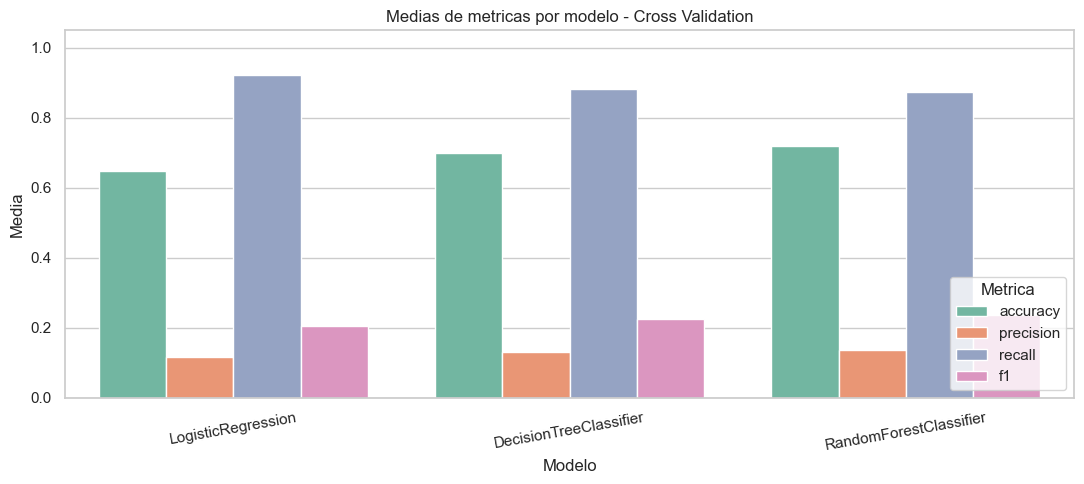

In [7]:
metrics_order = ["accuracy", "precision", "recall", "f1"]
means_long = cv_summary_long.copy()
means_long["metrica"] = pd.Categorical(means_long["metrica"], categories=metrics_order, ordered=True)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=means_long, x="modelo", y="media", hue="metrica", ax=ax)
ax.set_title("Medias de metricas por modelo - Cross Validation")
ax.set_xlabel("Modelo")
ax.set_ylabel("Media")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=10)
ax.legend(title="Metrica", loc="lower right")
plt.tight_layout()
plt.show()

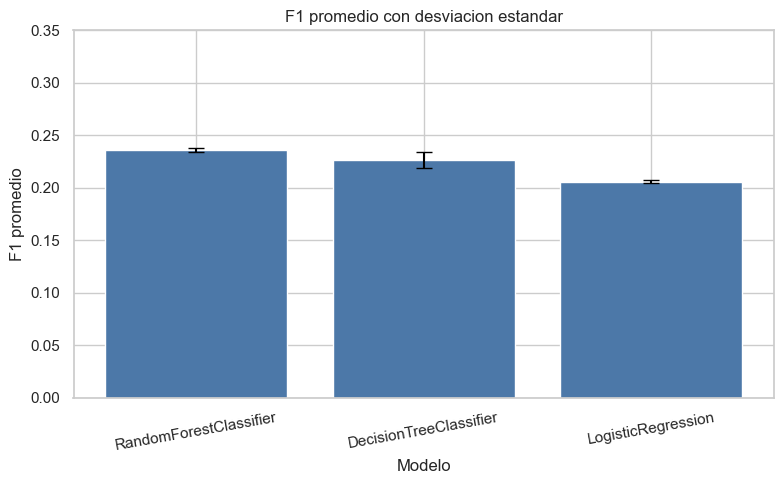

In [8]:
f1_plot_df = comparison_df[["modelo", "f1_mean", "f1_std"]].copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(f1_plot_df["modelo"], f1_plot_df["f1_mean"], yerr=f1_plot_df["f1_std"], capsize=6, color="#4C78A8")
ax.set_title("F1 promedio con desviacion estandar")
ax.set_xlabel("Modelo")
ax.set_ylabel("F1 promedio")
ax.set_ylim(0, max(0.35, float((f1_plot_df["f1_mean"] + f1_plot_df["f1_std"]).max()) + 0.05))
ax.tick_params(axis="x", rotation=10)
plt.tight_layout()
plt.show()

## Seleccion final

El modelo ganador se selecciona utilizando dos criterios ordenados: primero mayor F1 promedio, luego menor desviacion estandar de F1. Esta regla favorece modelos que detectan mejor la clase minoritaria manteniendo estabilidad entre folds.

In [9]:
best_row = comparison_df.iloc[0]
best_model = best_row["modelo"]

print(f"Modelo seleccionado para produccion: {best_model}")
print(f"F1 promedio: {best_row['f1_mean']:.4f}")
print(f"Desviacion estandar F1: {best_row['f1_std']:.4f}")
display(best_row.to_frame(name="valor"))

Modelo seleccionado para produccion: RandomForestClassifier
F1 promedio: 0.2360
Desviacion estandar F1: 0.0018


,valor
modelo,RandomForestClassifier
accuracy_mean,0.719215
accuracy_std,0.005921
precision_mean,0.136434
precision_std,0.001191
recall_mean,0.873731
recall_std,0.018261
f1_mean,0.235999
f1_std,0.001846


## Exportacion de resultados

Los resultados se exportan a `outputs/cross_validation_results.json`. Este archivo deja trazabilidad del criterio de seleccion final antes de almacenar el modelo en una etapa posterior.

In [10]:
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

payload = {
    "target": TARGET,
    "hypothesis": "Las caracteristicas de la victima y del contexto del siniestro permiten anticipar si el caso terminara siendo grave o mortal.",
    "cv_strategy": {
        "name": "StratifiedKFold",
        "n_splits": N_SPLITS,
        "shuffle": True,
        "random_state": RANDOM_STATE,
    },
    "selection_criteria": ["max_f1_mean", "min_f1_std"],
    "best_model": best_model,
    "best_model_metrics": best_row.drop(labels=["modelo"]).to_dict(),
    "features": {
        "numeric": numeric_features,
        "categorical": categorical_features,
        "excluded_leakage_or_target": excluded_features,
    },
    "data": {
        "n_rows": int(len(df)),
        "n_features": int(len(selected_features)),
        "positive_rate": float(y.mean()),
    },
    "comparison_table": comparison_df.to_dict(orient="records"),
    "fold_scores": fold_results,
}

with CV_RESULTS_FILE.open("w", encoding="utf-8") as file:
    json.dump(payload, file, ensure_ascii=False, indent=2)

print(f"Resultados exportados en: {CV_RESULTS_FILE.resolve()}")

Resultados exportados en: C:\Users\Germán\Desktop\TP AVANZADA\tp-final-siniestros-viales\outputs\cross_validation_results.json


## Cierre

La validacion cruzada entrega una seleccion mas robusta que una unica particion train/test. El modelo elegido queda justificado por F1 promedio y estabilidad entre folds; en la siguiente etapa podra entrenarse como candidato final y persistirse para uso posterior.